# Seasonality

## Theory

In an SIR model **with vital dynamics** (constant-population births and background
mortality), the system has an endemic equilibrium:

$$S^* = \frac{\gamma + \mu}{\beta},
\qquad I^* = \frac{\mu}{\gamma + \mu}\left(1 - \frac{1}{R_0}\right)N$$

where $\mu$ is the per-capita death (and birth) rate and
$R_0 = \beta / (\gamma + \mu)$.

Without forcing the system spirals toward the equilibrium via damped oscillations
whose period is approximately $2\pi / \sqrt{\mu\,(\beta - \gamma - \mu)}$.

Introducing a **seasonally-varying transmission rate**:

$$\beta(t) = \beta_0 \left(1 + \varepsilon\,\cos\left(\frac{2\pi t}{365}\right)\right)$$

prevents the damping from converging to a fixed point.  Even a small seasonal
amplitude $\varepsilon$ sustains **annual epidemic cycles** that persist indefinitely.

**Goal:** Run 10 years of simulation with and without seasonal forcing and compare
the resulting I(t) trajectories.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from laser.core import PropertySet
from laser.core.utils import grid
from laser.generic.utils import ValuesMap
from laser.cohorts import Model
from laser.cohorts.vitaldynamics import NonDiseaseMortality, ConstantPopBirths
import laser.cohorts.SIR as SIR

In [2]:
# --- Parameters ---
N       = 500_000
I0      = 50
beta0   = 0.5           # baseline transmission rate (per day)
gamma   = 0.1           # recovery rate (per day)
epsilon = 0.1           # seasonal forcing amplitude
nticks  = 10 * 365      # 10 years

# Crude death rate 20 per 1000 per year, converted to a daily rate
r_mortality_val = 20 / 1000 / 365

R0 = beta0 / (gamma + r_mortality_val)
print(f"R₀ (baseline) ≈ {R0:.2f}")
print(f"Daily mortality rate: {r_mortality_val:.6f}  ({r_mortality_val*365*1000:.1f} per 1000 per year)")

R₀ (baseline) ≈ 5.00
Daily mortality rate: 0.000055  (20.0 per 1000 per year)


In [3]:
# --- Build the seasonal forcing array ---
t_arr           = np.arange(nticks)
seasonal_factor = 1.0 + epsilon * np.cos(2 * np.pi * t_arr / 365)
# Shape (nticks, nnodes) — one node
seasonality     = np.tile(seasonal_factor[:, None], (1, 1))

# --- Scenario: single node ---
scenario = grid(M=1, N=1)
scenario["S"] = N - I0
scenario["I"] = I0
scenario["R"] = 0

params = PropertySet({"nticks": nticks, "beta": beta0, "r_recovery": gamma})
model  = Model(scenario, params)

betas        = ValuesMap.from_scalar(beta0, nticks, len(scenario))
r_recoveries = ValuesMap.from_scalar(gamma, nticks, len(scenario))

model.components = [
    SIR.Susceptible(model),
    SIR.Infectious(model,  r_recovery=r_recoveries),
    SIR.Recovered(model),
    NonDiseaseMortality(model, r_mortality=r_mortality_val),
    ConstantPopBirths(model),
    SIR.Transmission(model, beta=betas, seasonality=seasonality),
]
model.run()
print("Seasonal model run complete.")

Seasonal model run complete.


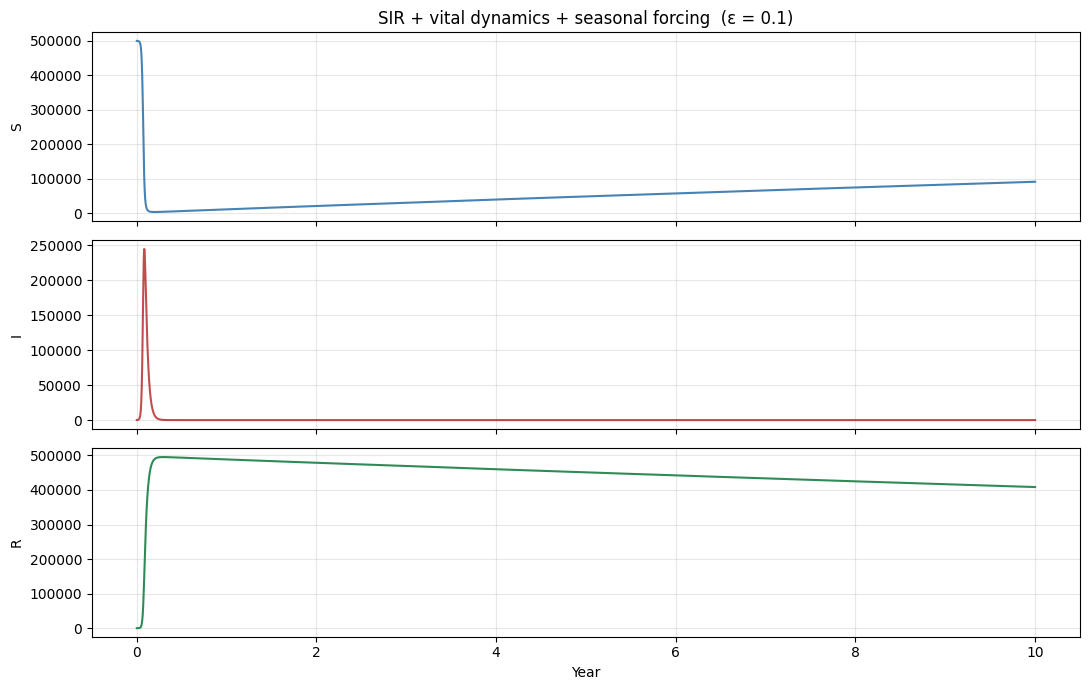

In [4]:
# --- Plot S, I, R over 10 years ---
years = np.arange(nticks + 1) / 365

S_s = model.states.S[:, 0]
I_s = model.states.I[:, 0]
R_s = model.states.R[:, 0]

fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)

axes[0].plot(years, S_s, color="steelblue")
axes[0].set_ylabel("S")
axes[0].set_title("SIR + vital dynamics + seasonal forcing  (ε = 0.1)")

axes[1].plot(years, I_s, color="firebrick", alpha=0.8)
axes[1].set_ylabel("I")

axes[2].plot(years, R_s, color="seagreen")
axes[2].set_ylabel("R")
axes[2].set_xlabel("Year")

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

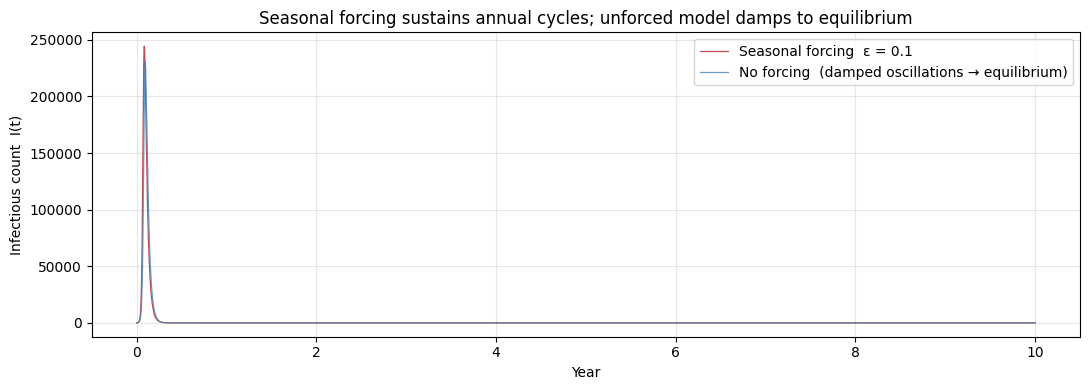

Approximate endemic I* ≈ 219
Unforced final I       = 0


In [5]:
# --- Second model: no seasonal forcing (epsilon = 0) ---
scenario2 = grid(M=1, N=1)
scenario2["S"] = N - I0
scenario2["I"] = I0
scenario2["R"] = 0

params2 = PropertySet({"nticks": nticks, "beta": beta0, "r_recovery": gamma})
model2  = Model(scenario2, params2)

betas2        = ValuesMap.from_scalar(beta0, nticks, len(scenario2))
r_recoveries2 = ValuesMap.from_scalar(gamma, nticks, len(scenario2))

# No seasonality array → transmission uses its default constant factor of 1
model2.components = [
    SIR.Susceptible(model2),
    SIR.Infectious(model2,  r_recovery=r_recoveries2),
    SIR.Recovered(model2),
    NonDiseaseMortality(model2, r_mortality=r_mortality_val),
    ConstantPopBirths(model2),
    SIR.Transmission(model2, beta=betas2),  # no seasonality
]
model2.run()

I_u = model2.states.I[:, 0]   # unforced

# --- Compare forced vs. unforced I(t) ---
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(years, I_s, color="firebrick", alpha=0.8, linewidth=0.9,
        label=f"Seasonal forcing  ε = {epsilon}")
ax.plot(years, I_u, color="steelblue",  alpha=0.8, linewidth=0.9,
        label="No forcing  (damped oscillations → equilibrium)")
ax.set_xlabel("Year")
ax.set_ylabel("Infectious count  I(t)")
ax.set_title("Seasonal forcing sustains annual cycles; unforced model damps to equilibrium")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

I_star_approx = r_mortality_val / (gamma + r_mortality_val) * (1 - 1/R0) * N
print(f"Approximate endemic I* ≈ {I_star_approx:,.0f}")
print(f"Unforced final I       = {I_u[-1]:,}")